<a href="https://colab.research.google.com/github/Eva360563/MaskArchitectureAnomaly_CourseProject/blob/main/Big_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/Eva360563/MaskArchitectureAnomaly_CourseProject.git
%cd MaskArchitectureAnomaly_CourseProject

fatal: destination path 'MaskArchitectureAnomaly_CourseProject' already exists and is not an empty directory.
/content/MaskArchitectureAnomaly_CourseProject


In [3]:
!pip install -r /content/MaskArchitectureAnomaly_CourseProject/eomt/requirements.txt
# If there is no requirements.txt, we will install the basics:
!pip install torch torchvision timm

In [4]:
!cat /content/MaskArchitectureAnomaly_CourseProject/eomt/requirements.txt


gitignore_parser==0.1.12
jsonargparse[signatures]==4.38
matplotlib==3.10.1
timm==1.0.15
wandb==0.19.10
lightning==2.5.1.post0
transformers==4.56.1
scipy==1.15.2
torch==2.7.0
torchvision==0.22.0
ipykernel==6.29.5
fvcore==0.1.5.post20221221
torchmetrics==1.7.1
pycocotools==2.0.8

In [5]:
!pip list | grep -E "torchvision|timm"

timm                                     1.0.15
torchvision                              0.22.0


In [6]:
import os

files_to_check = [
    #"/content/drive/MyDrive/cityscapes/leftImg8bit_trainvaltest.zip",
    #"/content/drive/MyDrive/cityscapes/gtFine_trainvaltest.zip",
    "/content/drive/MyDrive/Colab Notebooks/Trained_Datasets/Copia di eomt_cityscapes.bin",
    "/content/drive/MyDrive/Colab Notebooks/Trained_Datasets/Copia di eomt_coco.bin",
]

for f in files_to_check:
    exists = os.path.exists(f)
    print(f"{'✅' if exists else '❌'} {f}")

❌ /content/drive/MyDrive/Colab Notebooks/Trained_Datasets/Copia di eomt_cityscapes.bin
❌ /content/drive/MyDrive/Colab Notebooks/Trained_Datasets/Copia di eomt_coco.bin


In [7]:
import json

with open("/content/MaskArchitectureAnomaly_CourseProject/eomt/inference.ipynb") as f:
    nb = json.load(f)

for i, cell in enumerate(nb['cells']):
    print(f"\n--- Cella {i} ({cell['cell_type']}) ---")
    print("".join(cell['source']))


--- Cella 0 (markdown) ---
© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

--- Cella 1 (markdown) ---
## Setup

--- Cella 2 (code) ---
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0  # TODO: change to the GPU you want to use
img_idx = 0  # TODO: change to the index of the image you want to visualize
config_path = "configs/dinov2/coco/panoptic/eomt_giant_1280.yaml"  # TODO: change to the config file
data_path = "/mnt/sda1/tkerssies"  # TODO: change to the dataset directory

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np

In [8]:
import os

config_root = "/content/MaskArchitectureAnomaly_CourseProject/eomt/configs"
for root, dirs, files in os.walk(config_root):
    for f in files:
        print(os.path.join(root, f).replace(config_root, ""))

/dinov2/coco/panoptic/eomt_base_640_2x.yaml
/dinov2/cityscapes/semantic/eomt_base_640.yaml


In [10]:
import os, sys, yaml, warnings, importlib
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
from lightning import seed_everything

seed_everything(0, verbose=False)

# Paths - adatta se necessario
REPO = "/content/MaskArchitectureAnomaly_CourseProject/eomt"
CITYSCAPES_DATA = "/content/drive/MyDrive/Trained_Datasets"
CKPT_CS   = "/content/drive/MyDrive/Trained_Datasets/Copia di eomt_cityscapes.bin"
CKPT_COCO = "/content/drive/MyDrive/Trained_Datasets/Copia di eomt_coco.bin"
DEVICE = 0  # GPU

sys.path.insert(0, REPO)
os.chdir(REPO)
print("Setup ok")

Setup ok


In [11]:
def load_model(config_path, ckpt_path, data_path):
    with open(config_path) as f:
        config = yaml.safe_load(f)

    # Carica dataset
    data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
    data_cls = getattr(importlib.import_module(data_module_name), class_name)
    data_kwargs = config["data"].get("init_args", {})
    data = data_cls(
        path=data_path, batch_size=1, num_workers=0,
        check_empty_targets=False, **data_kwargs
    ).setup()

    # Carica encoder
    enc_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_cls = getattr(importlib.import_module(*enc_cfg["class_path"].rsplit(".",1)[::-1].__reversed__().__next__() and enc_cfg["class_path"].rsplit(".",1)), enc_cfg["class_path"].rsplit(".",1)[1])

    # (versione più leggibile)
    enc_module, enc_classname = enc_cfg["class_path"].rsplit(".", 1)
    enc_cls = getattr(importlib.import_module(enc_module), enc_classname)
    encoder = enc_cls(img_size=data.img_size, **enc_cfg.get("init_args", {}))

    # Carica network
    net_cfg = config["model"]["init_args"]["network"]
    net_module, net_classname = net_cfg["class_path"].rsplit(".", 1)
    net_cls = getattr(importlib.import_module(net_module), net_classname)
    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}
    network = net_cls(masked_attn_enabled=False, num_classes=data.num_classes,
                      encoder=encoder, **net_kwargs)

    # Carica Lightning module
    lit_module, lit_classname = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module), lit_classname)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = lit_cls(img_size=data.img_size, num_classes=data.num_classes,
                    network=network, **model_kwargs).eval().to(DEVICE)

    # Carica pesi LOCALI (dal Drive)
    state_dict = torch.load(ckpt_path, map_location=f"cuda:{DEVICE}", weights_only=True)
    model.load_state_dict(state_dict, strict=False)
    print(f"✅ Modello caricato da {ckpt_path}")

    return model, data

In [ ]:
model_cs, data_cs = load_model(
    config_path="configs/dinov2/cityscapes/semantic/eomt_base_640.yaml",
    ckpt_path=CKPT_CS,
    data_path=CITYSCAPES_DATA
)

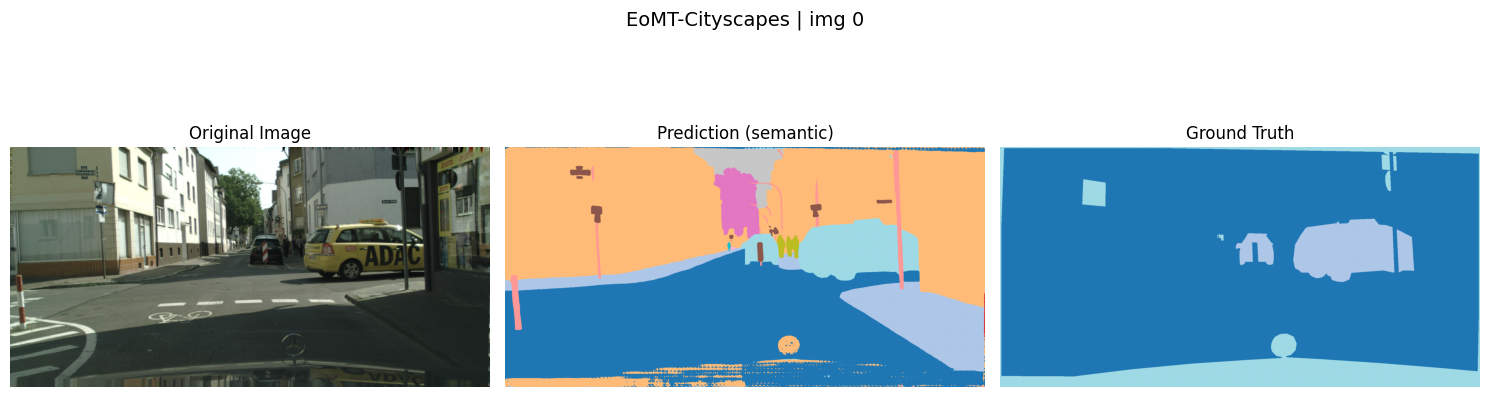

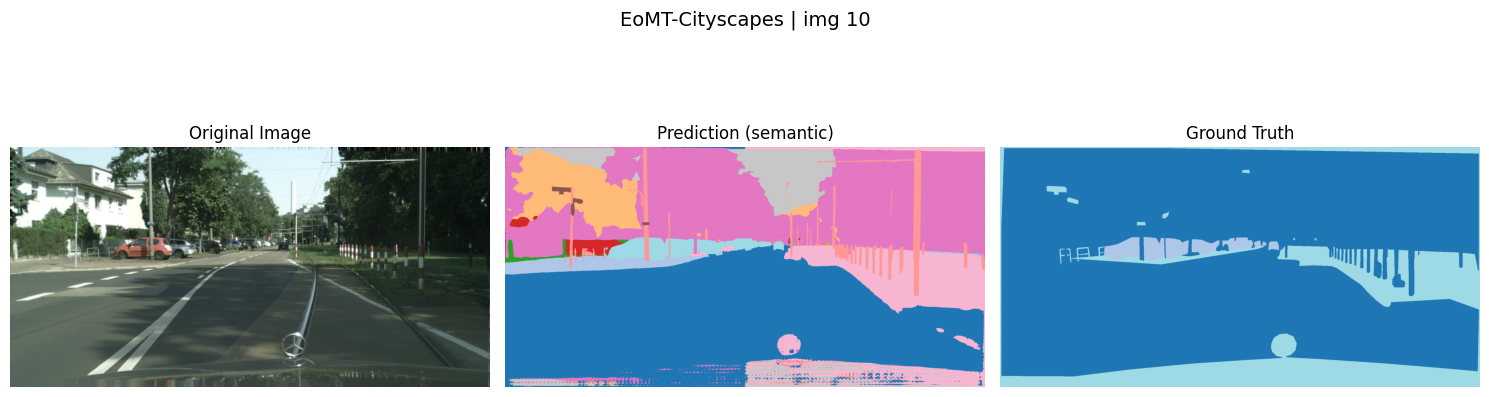

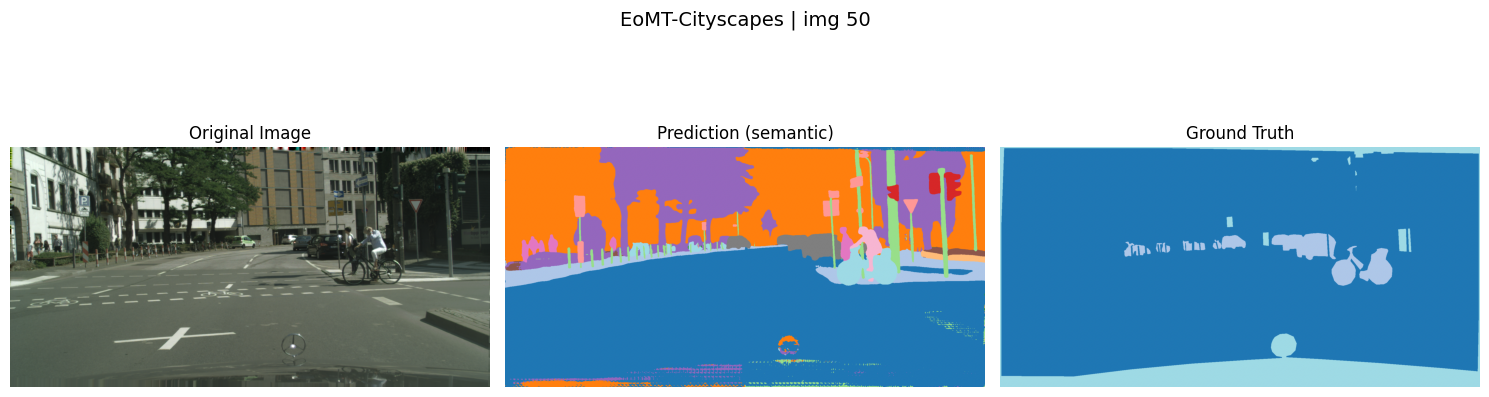

In [13]:
IGNORE_INDEX = 255

def visualize_semantic(model, data, img_idx=0, title="Cityscapes Model"):
    img, target = data.val_dataloader().dataset[img_idx]

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(DEVICE)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], data.img_size, mode="bilinear")
        crop_logits = model.to_per_pixel_logits_semantic(mask_logits, class_logits_per_layer[-1])
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        pred = logits[0].argmax(0).cpu().numpy()

    gt = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(title, fontsize=14)
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Original Image")
    axes[1].imshow(pred, cmap="tab20")
    axes[1].set_title("Prediction (semantic)")
    axes[2].imshow(gt, cmap="tab20")
    axes[2].set_title("Ground Truth")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"pred_cityscapes_img{img_idx}.png", dpi=150)
    plt.show()

# Visualizza 3 immagini diverse
for idx in [0, 10, 50]:
    visualize_semantic(model_cs, data_cs, img_idx=idx, title=f"EoMT-Cityscapes | img {idx}")

In [14]:
def load_model_only(config_path, ckpt_path, num_classes, img_size):
    """Carica solo il modello senza caricare il dataset."""
    with open(config_path) as f:
        config = yaml.safe_load(f)

    # Encoder
    enc_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_module, enc_classname = enc_cfg["class_path"].rsplit(".", 1)
    enc_cls = getattr(importlib.import_module(enc_module), enc_classname)
    encoder = enc_cls(img_size=img_size, **enc_cfg.get("init_args", {}))

    # Network
    net_cfg = config["model"]["init_args"]["network"]
    net_module, net_classname = net_cfg["class_path"].rsplit(".", 1)
    net_cls = getattr(importlib.import_module(net_module), net_classname)
    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}
    network = net_cls(masked_attn_enabled=False, num_classes=num_classes,
                      encoder=encoder, **net_kwargs)

    # Lightning module
    lit_module, lit_classname = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module), lit_classname)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    model = lit_cls(img_size=img_size, num_classes=num_classes,
                    network=network, **model_kwargs).eval().to(DEVICE)

    # Pesi locali
    state_dict = torch.load(ckpt_path, map_location=f"cuda:{DEVICE}", weights_only=True)
    model.load_state_dict(state_dict, strict=False)
    print(f"✅ Modello COCO caricato da {ckpt_path}")
    return model

# COCO panoptic: 133 classi, img_size 640
model_coco = load_model_only(
    config_path="configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml",
    ckpt_path=CKPT_COCO,
    num_classes=133,
    img_size=(640, 640)
)

✅ Modello COCO caricato da /content/drive/MyDrive/Trained_Datasets/Copia di eomt_coco.bin


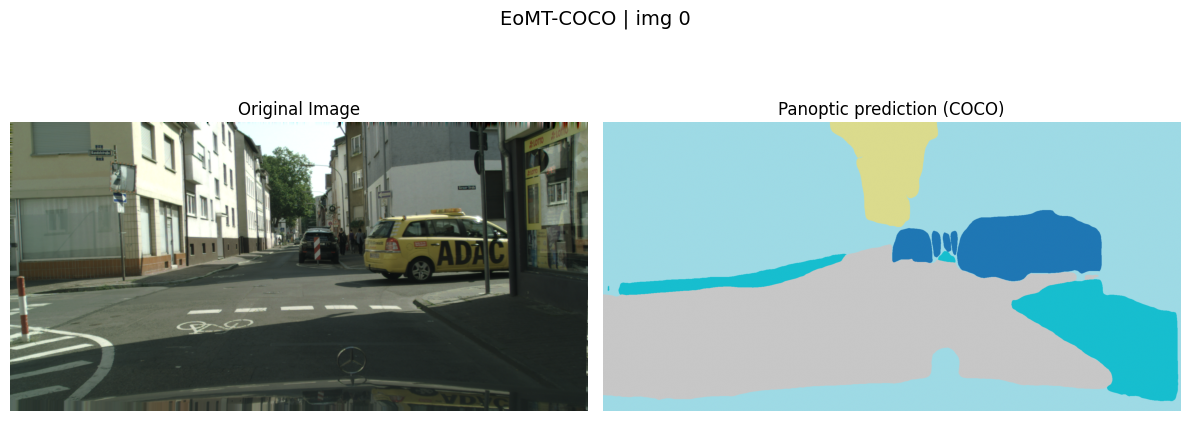

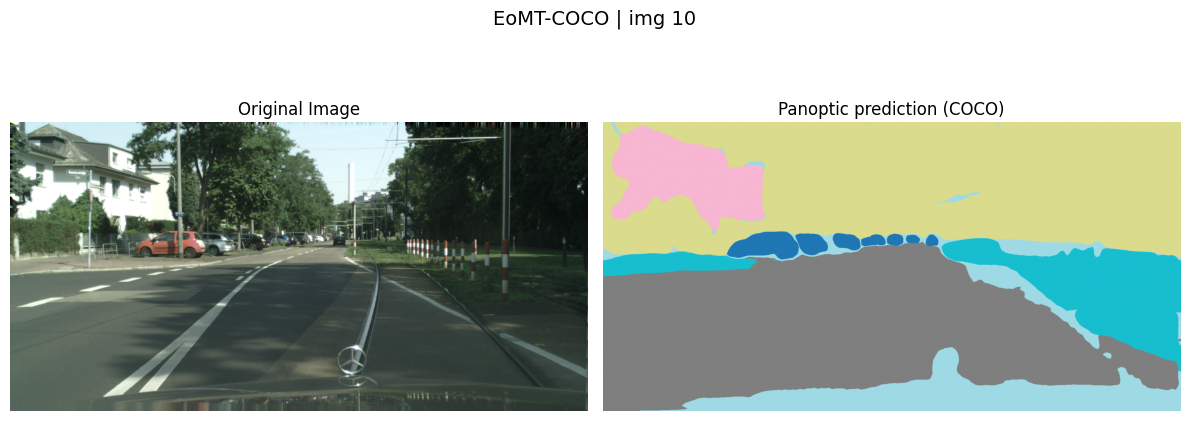

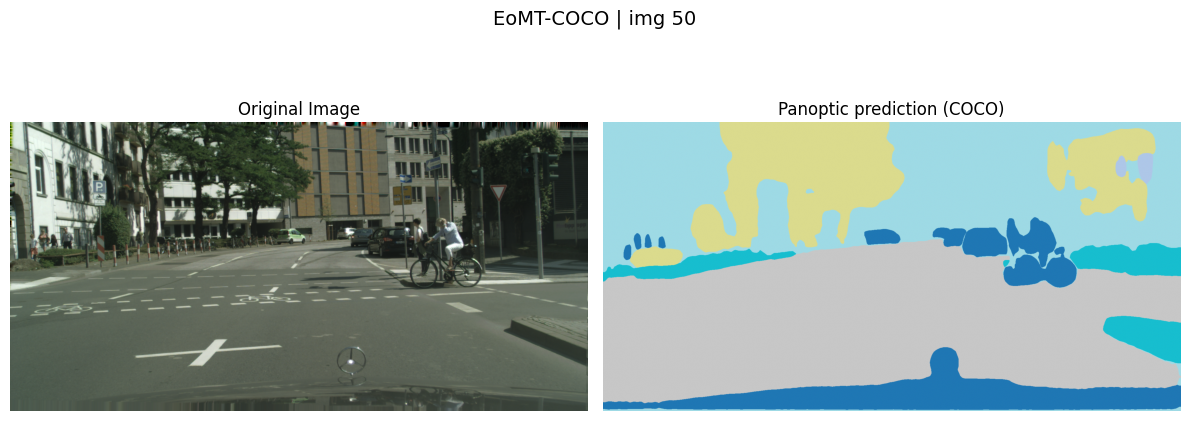

In [15]:
def visualize_panoptic(model, data, img_idx=0, title="COCO Model"):
    img, target = data.val_dataloader().dataset[img_idx]

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(DEVICE)]
        img_sizes = [img.shape[-2:] for img in imgs]
        transformed = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], model.img_size, mode="bilinear")
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(mask_logits, img_sizes)
        preds = model.to_per_pixel_preds_panoptic(
            mask_logits, class_logits_per_layer[-1],
            model.stuff_classes, model.mask_thresh, model.overlap_thresh,
        )[0].cpu().numpy()

    sem_pred = preds[..., 0]
    inst_pred = preds[..., 1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontsize=14)
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Original Image")
    axes[1].imshow(sem_pred, cmap="tab20")
    axes[1].set_title("Panoptic prediction (COCO)")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"pred_coco_img{img_idx}.png", dpi=150)
    plt.show()

for idx in [0, 10, 50]:
    visualize_panoptic(model_coco, data_cs, img_idx=idx, title=f"EoMT-COCO | img {idx}")

In [16]:
from torchmetrics.classification import MulticlassJaccardIndex

miou_cs = MulticlassJaccardIndex(num_classes=19, ignore_index=255).to(DEVICE)

print("Valuto EoMT-Cityscapes...")
for i, batch in enumerate(data_cs.val_dataloader()):
    img, target = batch[0], batch[1]

    # gestisci sia lista che tensor
    if isinstance(img, list):
        img = img[0]
    else:
        img = img.squeeze(0)

    if isinstance(target, list):
        target = target[0]
    else:
        target = target.squeeze(0)

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(DEVICE)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model_cs.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_cs(crops)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], data_cs.img_size, mode="bilinear")
        crop_logits = model_cs.to_per_pixel_logits_semantic(mask_logits, class_logits_per_layer[-1])
        logits = model_cs.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        pred = logits[0].argmax(0)

    gt = model_cs.to_per_pixel_targets_semantic([target], 255)[0].to(DEVICE)

    miou_cs.update(pred.unsqueeze(0), gt.unsqueeze(0))

    if i % 50 == 0:
        print(f"  {i}/500 immagini processate...")

result_cs = miou_cs.compute()
print(f"\n✅ mIoU EoMT-Cityscapes: {result_cs.item()*100:.2f}%")

Valuto EoMT-Cityscapes...
  0/500 immagini processate...
  50/500 immagini processate...
  100/500 immagini processate...
  150/500 immagini processate...
  200/500 immagini processate...
  250/500 immagini processate...
  300/500 immagini processate...
  350/500 immagini processate...
  400/500 immagini processate...
  450/500 immagini processate...

✅ mIoU EoMT-Cityscapes: 81.68%


In [20]:
from torchmetrics.classification import MulticlassJaccardIndex

# Mapping COCO → Cityscapes
COCO_TO_CS = {
    0:  [11, 12],  # person
    1:  18,  # bicycle
    2:  13,  # car
    3:  17,  # motorcycle
    5:  15,  # bus
    6:  16,  # train
    7:  14,  # truck
    9:  6,
    11: 7
}

def remap_coco_to_cityscapes(pred_coco):
    out = torch.full_like(pred_coco, 255)
    for coco_id, cs_ids in COCO_TO_CS.items():
        mask = (pred_coco == coco_id)
        if isinstance(cs_ids, list):
            # For person (coco 0): map to person (11) by default.
            # Rider (12) can't be recovered from COCO alone — no overlap info.
            out[mask] = cs_ids[0]   # → trainId 11 (person)
        else:
            out[mask] = cs_ids
    return out

# Valutazione
miou_coco = MulticlassJaccardIndex(num_classes=19, ignore_index=255).to(DEVICE)

print("Valuto EoMT-COCO su Cityscapes...")
for i, batch in enumerate(data_cs.val_dataloader()):
    img, target = batch[0], batch[1]
    if isinstance(img, list): img = img[0]
    else: img = img.squeeze(0)
    if isinstance(target, list): target = target[0]
    else: target = target.squeeze(0)

    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(DEVICE)]
        img_sizes = [img.shape[-2:] for img in imgs]
        transformed = model_coco.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_coco(transformed)
        mask_logits = F.interpolate(mask_logits_per_layer[-1], model_coco.img_size, mode="bilinear")
        mask_logits = model_coco.revert_resize_and_pad_logits_instance_panoptic(mask_logits, img_sizes)
        preds = model_coco.to_per_pixel_preds_panoptic(
            mask_logits, class_logits_per_layer[-1],
            model_coco.stuff_classes, model_coco.mask_thresh, model_coco.overlap_thresh,
        )[0].cpu()

    sem_pred = preds[..., 0].to(DEVICE)
    sem_pred_mapped = remap_coco_to_cityscapes(sem_pred)
    gt = model_cs.to_per_pixel_targets_semantic([target], 255)[0].to(DEVICE)

    ignore_mask = (gt == 255) | (sem_pred_mapped == 255)
    gt_eval = gt.clone()
    gt_eval[ignore_mask] = 255
    pred_eval = sem_pred_mapped.clone()
    pred_eval[ignore_mask]= 255
    miou_coco.update(pred_eval.unsqueeze(0), gt_eval.unsqueeze(0))

    if i % 50 == 0:
        print(f"  {i}/500 immagini processate...")

result_coco = miou_coco.compute()
print(f"\n✅ mIoU EoMT-COCO: {result_coco.item()*100:.2f}%")

Valuto EoMT-COCO su Cityscapes...
  0/500 immagini processate...
  50/500 immagini processate...
  100/500 immagini processate...
  150/500 immagini processate...
  200/500 immagini processate...
  250/500 immagini processate...
  300/500 immagini processate...
  350/500 immagini processate...
  400/500 immagini processate...
  450/500 immagini processate...

✅ mIoU EoMT-COCO: 28.40%


In [23]:
#IMPORT DEL MIO GITHUB
!git clone https://github.com/Eva360563/MaskArchitectureAnomaly_CourseProject.git
%cd MaskArchitectureAnomaly_CourseProject

Cloning into 'MaskArchitectureAnomaly_CourseProject'...
remote: Enumerating objects: 178, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 178 (delta 31), reused 25 (delta 25), pack-reused 107 (from 1)
Receiving objects: 100% (178/178), 30.88 MiB | 21.00 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/MaskArchitectureAnomaly_CourseProject/eomt/MaskArchitectureAnomaly_CourseProject/MaskArchitectureAnomaly_CourseProject


In [25]:
#UNZIP ANOMALY_VALIDATION_DATASET

import zipfile, os

zip_path = "/content/drive/MyDrive/Trained_Datasets/Copia di Anomaly_Validation_Datasets.zip"
extract_path = "/content/anomaly_datasets"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Dataset estratti:")
for f in os.listdir(extract_path):
    print(" ", f)

Dataset estratti:
  Validation_Dataset
  __MACOSX


In [26]:
for root, dirs, files in os.walk("/content/anomaly_datasets/Validation_Dataset"):
    level = root.replace("/content/anomaly_datasets/Validation_Dataset", "").count(os.sep)
    if level > 2:
        continue
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:
        print(f"{indent}  ... ({len(files)} files)")

Validation_Dataset/
  RoadAnomaly21/
    images/
      ... (10 files)
    labels_masks/
      ... (10 files)
  RoadObsticle21/
    images/
      ... (30 files)
    labels_masks/
      ... (30 files)
  FS_LostFound_full/
    images/
      ... (100 files)
    labels_masks/
      ... (100 files)
  RoadAnomaly/
    images/
      ... (60 files)
    labels_masks/
      ... (60 files)
  fs_static/
    images/
      ... (30 files)
    labels_masks/
      ... (30 files)


In [ ]:
!pip install ood-metrics scikit-learn -q
print("Setup ok")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 65.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incomp

In [27]:
import glob
import numpy as np
from PIL import Image

DATASETS = {
    "SMIYC_RA21":  "/content/anomaly_datasets/Validation_Dataset/RoadAnomaly21/labels_masks/*.png",
    "SMIYC_RO21":  "/content/anomaly_datasets/Validation_Dataset/RoadObsticle21/labels_masks/*.png",
    "FS_LaF":      "/content/anomaly_datasets/Validation_Dataset/FS_LostFound_full/labels_masks/*.png",
    "FS_Static":   "/content/anomaly_datasets/Validation_Dataset/fs_static/labels_masks/*.png",
    "RoadAnomaly": "/content/anomaly_datasets/Validation_Dataset/RoadAnomaly/labels_masks/*.png",
}

N_SAMPLES = 5

for name, pattern in DATASETS.items():
    print("\n" + "="*60)
    print("DATASET:", name)
    print("="*60)

    paths = glob.glob(pattern)

    if len(paths) == 0:
        print("⚠️ Nessun file trovato!")
        continue

    for i, p in enumerate(paths[:N_SAMPLES]):
        mask = np.array(Image.open(p))
        unique_vals = np.unique(mask)

        print(f"{i+1}. {p.split('/')[-1]}")
        print("   unique values:", unique_vals)

    print("\n")


DATASET: SMIYC_RA21
1. 8.png
   unique values: [  0   1 255]
2. 4.png
   unique values: [  0   1 255]
3. 3.png
   unique values: [  0   1 255]
4. 1.png
   unique values: [  0   1 255]
5. 0.png
   unique values: [  0   1 255]



DATASET: SMIYC_RO21
1. 12.png
   unique values: [  0   1 255]
2. 21.png
   unique values: [  0   1 255]
3. 8.png
   unique values: [  0   1 255]
4. 25.png
   unique values: [  0   1 255]
5. 17.png
   unique values: [  0   1 255]



DATASET: FS_LaF
1. 86.png
   unique values: [  0   1 255]
2. 12.png
   unique values: [  0   1 255]
3. 95.png
   unique values: [  0   1 255]
4. 21.png
   unique values: [  0   1 255]
5. 79.png
   unique values: [  0   1 255]



DATASET: FS_Static
1. 12.png
   unique values: [  0   1 255]
2. 21.png
   unique values: [  0   1 255]
3. 8.png
   unique values: [  0   1 255]
4. 25.png
   unique values: [  0   1 255]
5. 17.png
   unique values: [  0 255]



DATASET: RoadAnomaly
1. 12.png
   unique values: [0 2]
2. 21.png
   unique values: 

In [28]:
import subprocess

BASE = "/content/anomaly_datasets/Validation_Dataset"
WEIGHTS_DIR = "/content/MaskArchitectureAnomaly_CourseProject/trained_models/"
EVAL_DIR = "/content/MaskArchitectureAnomaly_CourseProject/eval"

DATASETS = {
    "SMIYC_RA21":  f"{BASE}/RoadAnomaly21/images/*.png",
    "SMIYC_RO21":  f"{BASE}/RoadObsticle21/images/*.webp",
    "FS_LaF":      f"{BASE}/FS_LostFound_full/images/*.png",
    "FS_Static":   f"{BASE}/fs_static/images/*.jpg",
    "RoadAnomaly": f"{BASE}/RoadAnomaly/images/*.jpg",
}
METHODS = ["msp", "maxlogit", "maxentropy"]

results = {}
for dataset_name, glob_pattern in DATASETS.items():
    results[dataset_name] = {}
    for method in METHODS:
        print(f"\n▶️ {dataset_name} | {method}")
        out = subprocess.run(
            ["python", "evalAnomaly.py",
             "--input", glob_pattern,
             "--loadDir", WEIGHTS_DIR,
             "--method", method],
            capture_output=True, text=True, cwd=EVAL_DIR
        )
        print(out.stdout[-300:] if out.stdout else "")
        if out.returncode != 0:
            print("ERRORE:", out.stderr[-300:])
        for line in out.stdout.split("\n"):
            if "AUPRC" in line or "FPR" in line:
                print(" →", line)
        results[dataset_name][method] = out.stdout


▶️ SMIYC_RA21 | msp

ERRORE: Traceback (most recent call last):
  File "/content/MaskArchitectureAnomaly_CourseProject/eval/evalAnomaly.py", line 12, in <module>
    from ood_metrics import fpr_at_95_tpr, calc_metrics, plot_roc, plot_pr,plot_barcode
ModuleNotFoundError: No module named 'ood_metrics'


▶️ SMIYC_RA21 | maxlogit

ERRORE: Traceback (most recent call last):
  File "/content/MaskArchitectureAnomaly_CourseProject/eval/evalAnomaly.py", line 12, in <module>
    from ood_metrics import fpr_at_95_tpr, calc_metrics, plot_roc, plot_pr,plot_barcode
ModuleNotFoundError: No module named 'ood_metrics'


▶️ SMIYC_RA21 | maxentropy

ERRORE: Traceback (most recent call last):
  File "/content/MaskArchitectureAnomaly_CourseProject/eval/evalAnomaly.py", line 12, in <module>
    from ood_metrics import fpr_at_95_tpr, calc_metrics, plot_roc, plot_pr,plot_barcode
ModuleNotFoundError: No module named 'ood_metrics'


▶️ SMIYC_RO21 | msp

ERRORE: Traceback (most recent call last):
  File "/conte

In [ ]:
import os
import glob
import torch
import random
from PIL import Image
import numpy as np
from erfnet import ERFNet
from argparse import ArgumentParser
from sklearn.metrics import average_precision_score
from ood_metrics import fpr_at_95_tpr
from torchvision.transforms import Compose, Resize, ToTensor
import torch.nn.functional as F

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

NUM_CLASSES = 20
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

input_transform = Compose([
    Resize((512, 1024), Image.BILINEAR),
    ToTensor(),
])
target_transform = Compose([
    Resize((512, 1024), Image.NEAREST),
])

def get_anomaly_score(result, method):
    logits = result.squeeze(0)
    if method == "maxlogit":
        return 1.0 - np.max(logits.data.cpu().numpy(), axis=0)
    elif method == "msp":
        probs = F.softmax(logits, dim=0)
        return 1.0 - np.max(probs.data.cpu().numpy(), axis=0)
    elif method == "maxentropy":
        probs = F.softmax(logits, dim=0)
        entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=0)
        return entropy.data.cpu().numpy()

def main():
    parser = ArgumentParser()
    parser.add_argument("--input", default="", nargs="+")
    parser.add_argument("--loadDir", default="../trained_models/")
    parser.add_argument("--loadWeights", default="erfnet_pretrained.pth")
    parser.add_argument("--method", default="maxlogit",
                        choices=["msp", "maxlogit", "maxentropy"])
    parser.add_argument("--cpu", action="store_true")
    args = parser.parse_args()

    model = ERFNet(NUM_CLASSES)
    if not args.cpu:
        model = torch.nn.DataParallel(model).cuda()

    def load_my_state_dict(model, state_dict):
        own_state = model.state_dict()
        for name, param in state_dict.items():
            if name not in own_state:
                if name.startswith("module."):
                    own_state[name.split("module.")[-1]].copy_(param)
            else:
                own_state[name].copy_(param)
        return model

    weightspath = args.loadDir + args.loadWeights
    model = load_my_state_dict(model, torch.load(weightspath, map_location="cpu"))
    print(f"Modello caricato | Metodo: {args.method}")
    model.eval()

    anomaly_score_list = []
    ood_gts_list = []

    for path in glob.glob(os.path.expanduser(str(args.input[0]))):
        images = input_transform(Image.open(path).convert("RGB")).unsqueeze(0).float()
        if not args.cpu:
            images = images.cuda()

        with torch.no_grad():
            result = model(images)

        anomaly_result = get_anomaly_score(result, args.method)

        pathGT = path.replace("images", "labels_masks")
        if "RoadObsticle21" in pathGT: pathGT = pathGT.replace("webp", "png")
        if "fs_static" in pathGT: pathGT = pathGT.replace("jpg", "png")
        if "RoadAnomaly" in pathGT: pathGT = pathGT.replace("jpg", "png")

        mask = Image.open(pathGT)
        ood_gts = np.array(target_transform(mask))

        if "RoadAnomaly" in pathGT:
           ood_gts = (ood_gts == 2).astype(np.uint8)
        else:
            # SMIYC + FS datasets
            ood_gts = (ood_gts == 255).astype(np.uint8)

        if 1 not in np.unique(ood_gts):
            continue
        ood_gts_list.append(ood_gts)
        anomaly_score_list.append(anomaly_result)
        torch.cuda.empty_cache()

    if len(ood_gts_list) == 0:
        print("Nessuna immagine valida trovata!")
        return

    ood_gts = np.array(ood_gts_list)
    anomaly_scores = np.array(anomaly_score_list)

    ood_out = anomaly_scores[ood_gts == 1]
    ind_out = anomaly_scores[ood_gts == 0]

    val_out = np.concatenate((ind_out, ood_out))
    val_label = np.concatenate((np.zeros(len(ind_out)), np.ones(len(ood_out))))

    prc_auc = average_precision_score(val_label, val_out)
    fpr = fpr_at_95_tpr(val_out, val_label)

    print(f"AuPRC: {prc_auc*100:.2f}%  |  FPR95: {fpr*100:.2f}%")

if __name__ == "__main__":
    main()